# Data Analysis

In [1]:
import os
import numpy as np
import pandas as pd
import datetime as dt

import matplotlib.pyplot as plt
from   matplotlib.patches import Patch

# Paths and Global Variables

In [2]:
day_renamer = {
    "day_after"   : "Day After",
    "day_before"  : "Day Before",
    "post_meeting": "Post Meeting",
    "pre_meeting" : "Pre Meeting"}

replacer = {**day_renamer}

In [3]:
day_renamer_ = {
    "Day After"   : "Day\nAfter",
    "Day Before"  : "Day\nBefore",
    "Post Meeting": "Post\nMeeting",
    "Pre Meeting" : "Pre\nMeeting"}

plot_replacer = {**day_renamer_}

In [4]:
float_format="%.2f"

In [5]:
note_path = os.getcwd()
repo_path = os.path.abspath(os.path.join(note_path, ".."))
data_path = os.path.join(repo_path, "data")
zone_path = os.path.join(data_path, "ZoneImputedFirstRateData")

# Data Quality and EDA

We picked our predefined trading windows and then sliced the 1 minute bar data at that level and now we are examining the number of data points. 

In [6]:
df_raw = (pd
    .read_parquet(
        path   = zone_path,
        engine = "pyarrow"))

We can use the prior bar's close to work with the open price. 

In [7]:
(df_raw
    [["ticker", "variable", "meeting_id"]]
    .groupby(["ticker", "variable"])
    .agg("count")
    .reset_index()
    .rename(columns = {
        "variable": "",
        "ticker"  : "Ticker"})
    .pivot(index = "Ticker", columns = "", values = "meeting_id")
    .rename(columns = {
        "missing"    : "Missing",
        "open"       : "Orig Open",
        "prior_close": "Prior Close"}))

,Missing,Orig Open,Prior Close
Ticker,,,
TN,732,77445,2267
UB,818,126549,2681
US,2280,146353,1021
ZF,1231,144314,887
ZN,1526,146072,219
ZQ,79533,22777,10239
ZT,3298,136377,7570


# Start by Analyzing Returns

We'll just examine the returns for the single day

In [33]:
path = r"A:\GitHub\FOMCDrift\data\ZoneFirstRateData"
df_meeting_id = (pd
    .read_parquet(path = path, engine = "pyarrow")
    [["fomc_date", "meeting_id"]]
    .drop_duplicates())

In [49]:
path   = r"A:\GitHub\FOMCDrift\data\RawFirstRateData"
df_raw = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .assign(
        exact_date      = lambda x: pd.to_datetime(x.fomc_date.astype(str) + " " + str(dt.time(hour = 12 + 2, minute = 0))),
        days_to_meeting = lambda x: x.date - x.exact_date,
        tmp             = lambda x: x.days_to_meeting.dt.days)
    .loc[lambda x: (x.tmp >= -2) & (x.tmp <= 2)])

In [99]:
tickers = [
    ticker for ticker in df_raw.ticker.drop_duplicates().to_list()
    if ticker != "ZQ"]

In [100]:
df_rtn = (df_raw
    .loc[lambda x: x.variable == "open"]
    .merge(right = df_meeting_id, how = "inner", on = ["fomc_date"])
    [["ticker", "days_to_meeting", "meeting_id", "value"]]
    .set_index("days_to_meeting")
    .groupby(["ticker", "meeting_id"])
    .apply(lambda x: x.sort_index().value.diff() / x.sort_index().value.diff().ewm(span = 10, adjust = False).std())
    .to_frame(name = "rtn")
    .assign(rtn = lambda x: np.where(np.abs(x.rtn) > 50, np.nan, x.rtn))
    .reset_index())

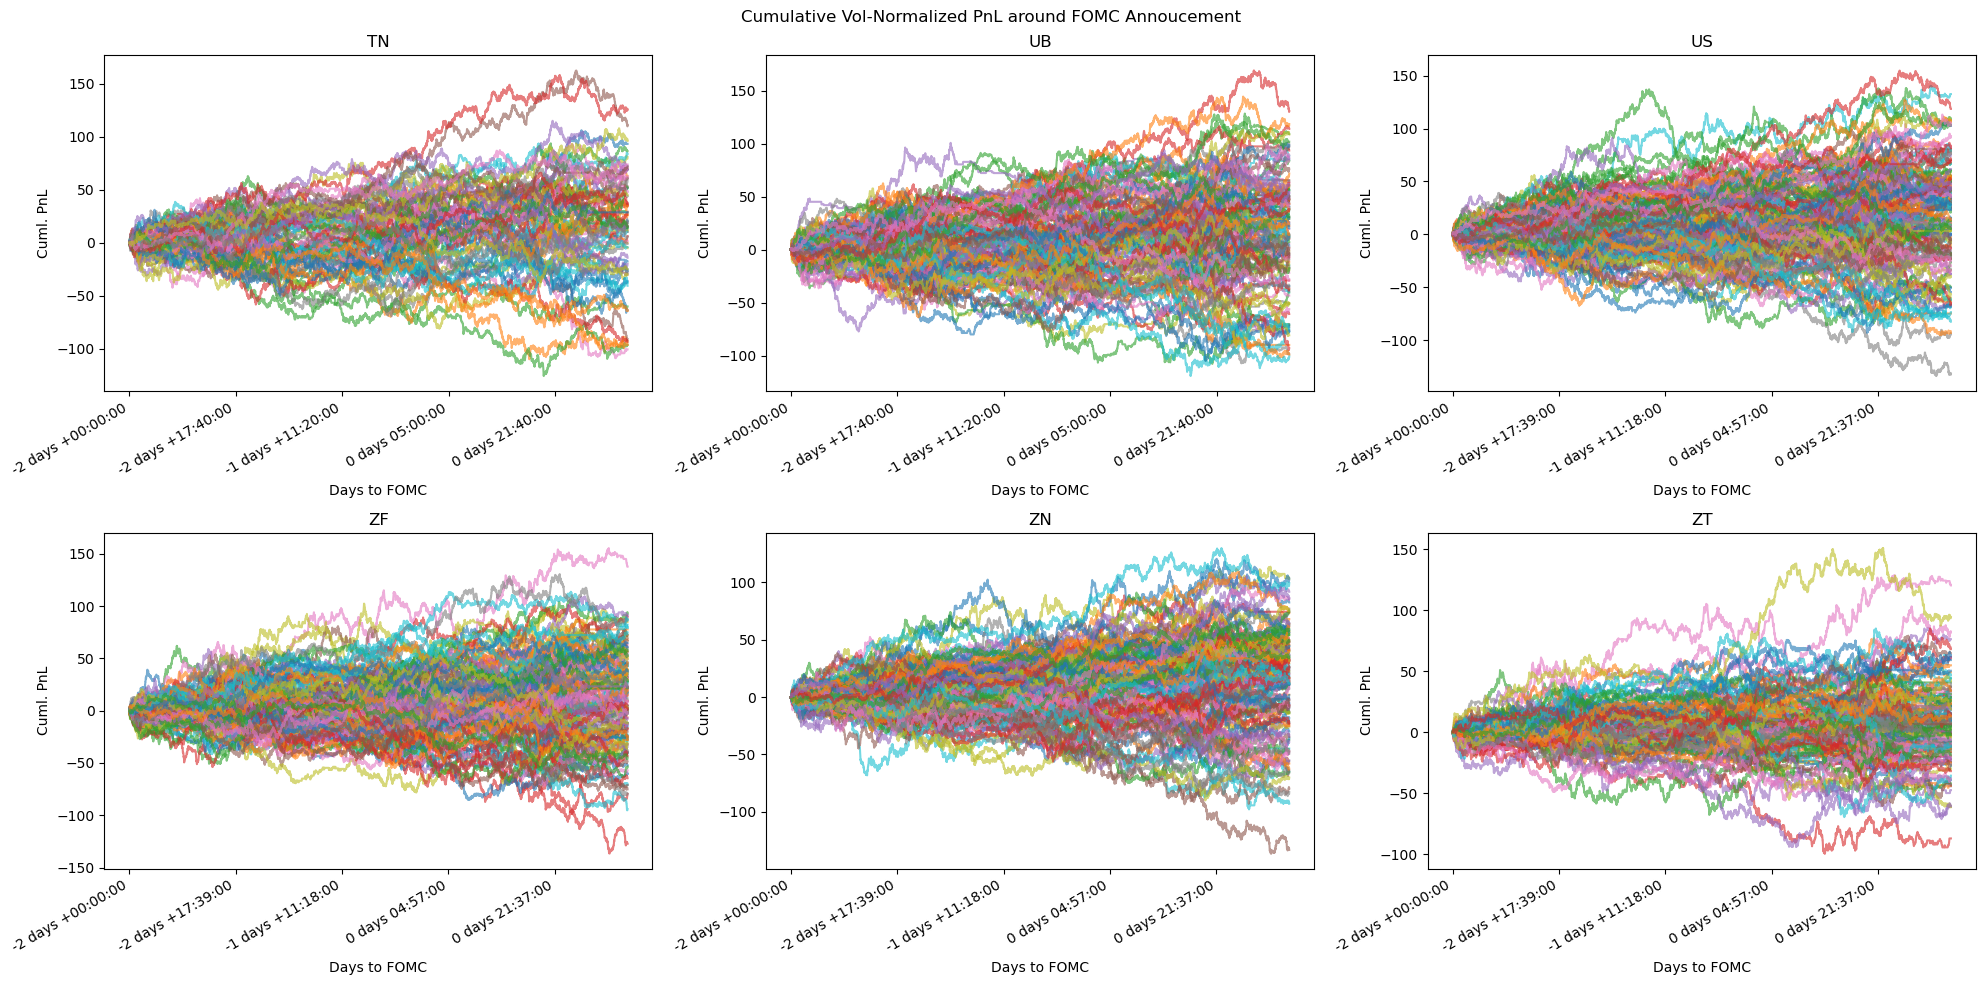

In [89]:
fig, axes = plt.subplots(ncols = len(tickers) // 2, nrows =2, figsize = (20,10))

for ticker, ax in zip(tickers, axes.flatten()):

    (df_rtn
        .loc[lambda x: x.ticker == ticker]
        .pivot(index = "days_to_meeting", columns = "meeting_id", values = "rtn")
        .fillna(0)
        .cumsum()
        .plot(
            title  = ticker,
            ax     = ax,
            legend = False,
            alpha  = 0.6,
            xlabel = "Days to FOMC",
            ylabel = "Cuml. PnL"))

fig.suptitle("Cumulative Vol-Normalized PnL around FOMC Annoucement")
plt.tight_layout()

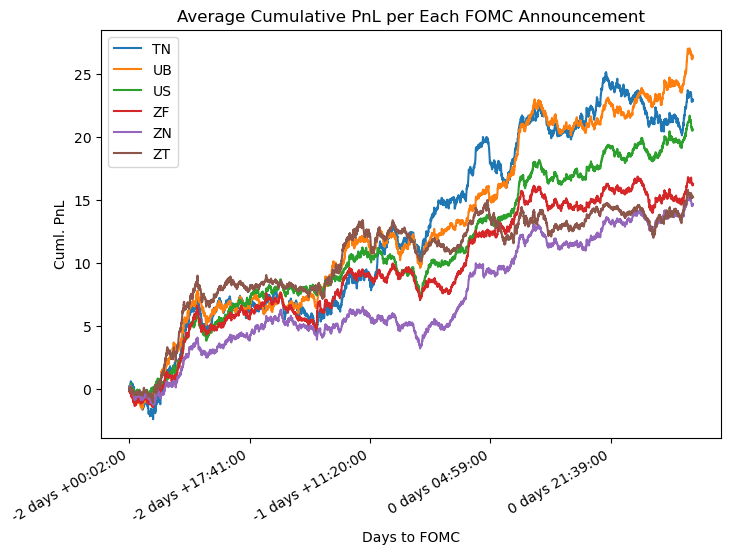

In [108]:
(df_rtn
    .dropna()
    .drop(columns = ["meeting_id"])
    .loc[lambda x: x.ticker.isin(tickers)]
    .groupby(["days_to_meeting", "ticker"])
    .agg("mean")
    .reset_index()
    .rename(columns = {"ticker": ""})
    .pivot(index = "days_to_meeting", columns = "", values = "rtn")
    .cumsum()
    .plot(
        ylabel  = "Cuml. PnL",
        title   = "Average Cumulative PnL per Each FOMC Announcement",
        xlabel  = "Days to FOMC",
        figsize = (8,6)))

plt.show()

In [141]:
df_tmp_raw = (df_raw
    .loc[lambda x: x.variable == "open"]
    .merge(right = df_meeting_id, how = "inner", on = ["fomc_date"])
    [["ticker", "days_to_meeting", "meeting_id", "value"]]
    .set_index("days_to_meeting")
    .groupby(["ticker", "meeting_id"])
    .apply(lambda x: x.sort_index().value.diff())
    .to_frame(name = "rtn")
    .assign(rtn = lambda x: np.where(np.abs(x.rtn) > 50, np.nan, x.rtn))
    .reset_index())

<Axes: ylabel='Frequency'>

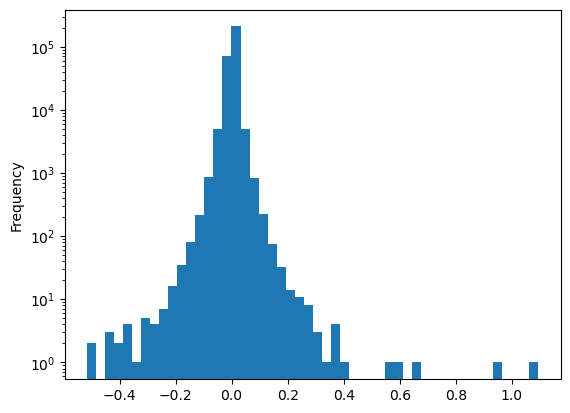

In [148]:
(df_tmp_raw
    .loc[lambda x: x.ticker == x.ticker.min()]
    .rtn
    .plot(kind = "hist", bins = 50, logy = True))